In [12]:
#get Data
#get data from GitHub -> https://github.com/keuperj/DATA
!git clone https://github.com/keuperj/DATA.git

fatal: destination path 'DATA' already exists and is not an empty directory.


# Ex 1.2: A simple parallel MapReduce framework in Python
Now we use the [*multiprocessing*](https://docs.python.org/3/library/multiprocessing.html) lib to actually do things in parallel

In [13]:
import collections
import itertools
import multiprocessing


class SimpleMapReduce:

    def __init__(self, map_func, reduce_func, num_workers=None):
        """
        map_func

          Function to map inputs to intermediate data. Takes as
          argument one input value and returns a tuple with the
          key and a value to be reduced.

        reduce_func

          Function to reduce partitioned version of intermediate
          data to final output. Takes as argument a key as
          produced by map_func and a sequence of the values
          associated with that key.

        num_workers

          The number of workers to create in the pool. Defaults
          to the number of CPUs available on the current host.
        """
        self.map_func = map_func
        self.reduce_func = reduce_func
        self.pool = multiprocessing.Pool(num_workers)

    def partition(self, mapped_values):
        """Organize the mapped values by their key.
        Returns an unsorted sequence of tuples with a key
        and a sequence of values.
        """
        partitioned_data = collections.defaultdict(list)
        for key, value in mapped_values:
            partitioned_data[key].append(value)
        return partitioned_data.items()

    def __call__(self, inputs, chunksize=1):
        """Process the inputs through the map and reduce functions
        given.

        inputs
          An iterable containing the input data to be processed.

        chunksize=1
          The portion of the input data to hand to each worker.
          This can be used to tune performance during the mapping
          phase.
        """
        map_responses = self.pool.map(
            self.map_func,
            inputs,
            chunksize=chunksize,
        )
        partitioned_data = self.partition(
            itertools.chain(*map_responses)
        )
        reduced_values = self.pool.map(
            self.reduce_func,
            partitioned_data,
        )
        return reduced_values

### A Word Count example

In [14]:
import string

# map - read file and count words
def file_to_words(filename):
    """Read a file and return a sequence of
    (word, occurences) values.
    """
    STOP_WORDS = set([
        'a', 'an', 'and', 'are', 'as', 'be', 'by', 'for', 'if',
        'in', 'is', 'it', 'of', 'or', 'py', 'rst', 'that', 'the',
        'to', 'with',
    ])
    TR = str.maketrans({
        p: ' '
        for p in string.punctuation
    })

    print('{} reading {}'.format(
        multiprocessing.current_process().name, filename))
    output = []

    with open(filename, 'rt') as f:
        for line in f:
            # Skip comment lines.
            if line.lstrip().startswith('..'):
                continue
            line = line.translate(TR)  # Strip punctuation
            for word in line.split():
                word = word.lower()
                if word.isalpha() and word not in STOP_WORDS:
                    output.append((word, 1))
    return output

# reduce
def count_words(item):
    """Convert the partitioned data for a word to a
    tuple containing the word and the number of occurences.
    """
    word, occurences = item
    return (word, sum(occurences))

In [15]:
import operator
import glob #easy file access

input_files = glob.glob('DATA/*.rst')#get all text files names

mapper = SimpleMapReduce(file_to_words, count_words)#get mapreduce instance with custom map and reduce functions
word_counts = mapper(input_files)#call parallel mapreduce on files

word_counts.sort(key=operator.itemgetter(1))#sort results
word_counts.reverse()

print('\nTOP 20 WORDS BY FREQUENCY\n')
top20 = word_counts[:20]
longest = max(len(word) for word, count in top20)
for word, count in top20:
    print('{word:<{len}}: {count:5}'.format(
            len=longest + 1,
            word=word,
            count=count)
    )

ForkPoolWorker-3 reading DATA/text1.rstForkPoolWorker-4 reading DATA/text3.rst

ForkPoolWorker-4 reading DATA/text2.rst
ForkPoolWorker-3 reading DATA/text4.rst

TOP 20 WORDS BY FREQUENCY

my    :    67
i     :    60
her   :    43
he    :    41
quiz  :    33
quick :    28
was   :    28
his   :    23
fox   :    22
she   :    21
when  :    20
from  :    20
blind :    19
vex   :    18
have  :    18
would :    18
but   :    18
so    :    18
on    :    17
then  :    16


## K-Means implementation
Use the simple frame work to implement K-Means

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

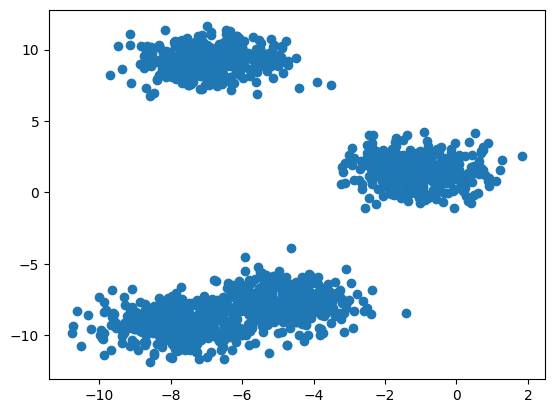

In [17]:
#generate data with K=4
X, y = make_blobs(n_samples=1500, centers=4)
plt.scatter(X[:, 0], X[:, 1])

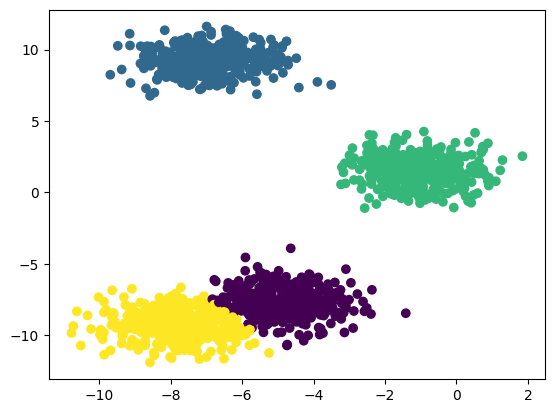

In [18]:
#K-Means ref implementation
k = KMeans(n_clusters=4, random_state=42)
y_pred = k.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred)

In [40]:
k.cluster_centers_
aktuelle_zenter= k.cluster_centers_

In [57]:
from functools import partial
#implement map -> assign data to center
def kMap(daten,centroiden):
  # print(len(k.cluster_centers_))
  ergebnis = {}
  zentrum_werte = centroiden[0]
  zentrum_l = 0
  ergebnis[str(daten)] = 0
  for i,ks in enumerate(centroiden):
    # print(i,ks)
    if abs((daten[0]-ks[0])+(daten[1]-ks[1])) <= abs((daten[0]-zentrum_werte[0])+(daten[1]-zentrum_werte[1])):
      zentrum_werte = ks
      zentrum_l = i
      ergebnis[str(daten)] = i
  return ergebnis

#print(X)
print(list(map(partial(kMap,centroiden=aktuelle_zenter),X)))

[{'[-1.21692414  1.218628  ]': 2}, {'[-0.44807119  1.47798898]': 2}, {'[ -7.76244451 -11.05651615]': 3}, {'[-4.62587644 -8.05920662]': 0}, {'[-8.73151093 -8.24450109]': 3}, {'[-5.46306127 -8.44532155]': 0}, {'[-4.2137637  -6.91737701]': 0}, {'[-6.89317909  7.72582374]': 2}, {'[-1.09602839  1.06775733]': 2}, {'[-1.97017268  2.71369431]': 2}, {'[-5.5794723  -8.16874779]': 0}, {'[-4.07098979 -7.0392647 ]': 0}, {'[-2.08274784  0.85306225]': 2}, {'[-7.28394268 10.40643114]': 1}, {'[-6.1199923  -7.16647658]': 0}, {'[-1.82984114  0.88975796]': 2}, {'[-6.43584209 -9.02122457]': 3}, {'[-1.77868458  1.37834178]': 2}, {'[-0.89882419  1.3009141 ]': 2}, {'[-7.31117752 10.55235573]': 1}, {'[-5.0371196  -8.29517647]': 0}, {'[-2.66061738  2.19126791]': 2}, {'[-7.96332492  9.32673241]': 2}, {'[-7.02029736  8.19996823]': 2}, {'[-7.97048466 -9.5650605 ]': 3}, {'[-8.80547416 -9.81865634]': 3}, {'[-8.40436968 -9.28594814]': 3}, {'[ -7.50205399 -10.2696012 ]': 3}, {'[-7.78774864 -9.00535161]': 3}, {'[-7.407

In [21]:
#implement reduce -> compute new centers
def kReduce( ... ):


SyntaxError: invalid syntax (16375174.py, line 2)

In [ ]:
#init centers
center = X[np.random.randint(X.shape[0], size=4), :]#get 4 random datapoints
print('init center', center)

In [ ]:
#use framework
mapper = SimpleMapReduce(kMap, kReduce)#get mapreduce instance with custom map and reduce functions
center = mapper(X)#call parallel mapreduce oo data